In [1]:
import sqlite3

# Create a new database file (in Colab's temp storage)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create the sales table
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
);
''')

# Insert sample data
cursor.executemany('''
INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)
''', [
    ('Laptop', 2, 50000),
    ('Phone', 5, 20000),
    ('Tablet', 3, 15000),
    ('Laptop', 1, 52000),
    ('Phone', 2, 21000)
])

conn.commit()


In [2]:
import pandas as pd

query = '''
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
'''

df = pd.read_sql_query(query, conn)
print("Sales Summary:\n", df)


Sales Summary:
   product  total_qty   revenue
0  Laptop          3  152000.0
1   Phone          7  142000.0
2  Tablet          3   45000.0


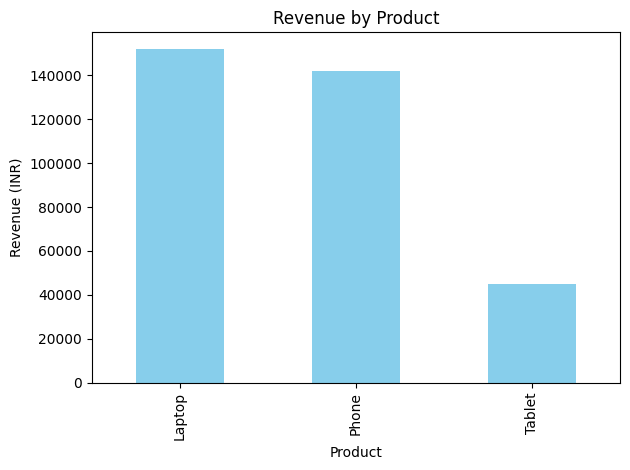

In [3]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (INR)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()


In [4]:
from google.colab import files
files.download("sales_data.db")
files.download("sales_chart.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>